In [1]:
# ===========================================================
# FedBrainGAN - BraTS2020 Preprocessing (Single Cell)
# ===========================================================

import os
import glob
import cv2
import numpy as np
import nibabel as nib
from tqdm import tqdm
from scipy.ndimage import zoom

# ===========================================================
# Dataset Paths
# ===========================================================

TRAIN_PATH = r"C:\Users\MONISH\Desktop\classification\BraTS2020_TrainingData\traindata\MICCAI_BraTS2020_TrainingData"

OUTPUT_ROOT = r"D:\output"

OUTPUT_NIFTI = os.path.join(OUTPUT_ROOT, "processed_nifti")
OUTPUT_PNG = os.path.join(OUTPUT_ROOT, "processed_png")

os.makedirs(OUTPUT_NIFTI, exist_ok=True)
os.makedirs(OUTPUT_PNG, exist_ok=True)

# ===========================================================
# Resize Function
# ===========================================================

TARGET_SIZE = (64,64,64)

def resize_volume(img):

    factors = (
        TARGET_SIZE[0]/img.shape[0],
        TARGET_SIZE[1]/img.shape[1],
        TARGET_SIZE[2]/img.shape[2]
    )

    img = zoom(img, factors, order=1)

    return img


# ===========================================================
# Normalization
# ===========================================================

def normalize(img):

    img = img.astype(np.float32)

    img = (img-img.min())/(img.max()-img.min()+1e-8)

    return img


# ===========================================================
# Save PNG Slices
# ===========================================================

def save_png(volume, patient):

    patient_folder = os.path.join(OUTPUT_PNG, patient)

    os.makedirs(patient_folder, exist_ok=True)

    for i in range(volume.shape[2]):

        slice_img = volume[:,:,i]

        slice_img = (slice_img*255).astype(np.uint8)

        cv2.imwrite(
            os.path.join(patient_folder,f"slice_{i:03d}.png"),
            slice_img
        )


# ===========================================================
# Processing Starts
# ===========================================================

patients = sorted(os.listdir(TRAIN_PATH))

print("="*60)
print("FedBrainGAN Dataset Preprocessing")
print("="*60)
print("Total Patients :",len(patients))
print()

processed = 0

for patient in tqdm(patients):

    patient_folder = os.path.join(TRAIN_PATH,patient)

    flair = glob.glob(os.path.join(patient_folder,"*_flair.nii*"))

    if len(flair)==0:
        continue

    flair = flair[0]

    volume = nib.load(flair)

    image = volume.get_fdata()

    image = normalize(image)

    image = resize_volume(image)

    nib.save(
        nib.Nifti1Image(image.astype(np.float32),np.eye(4)),
        os.path.join(
            OUTPUT_NIFTI,
            patient+".nii.gz"
        )
    )

    save_png(image,patient)

    processed += 1

print()
print("="*60)
print("Preprocessing Finished Successfully")
print("="*60)
print("Patients Processed :",processed)
print("NIfTI Saved To     :",OUTPUT_NIFTI)
print("PNG Saved To       :",OUTPUT_PNG)
print("="*60)

FedBrainGAN Dataset Preprocessing
Total Patients : 371



100%|██████████| 371/371 [02:00<00:00,  3.09it/s]


Preprocessing Finished Successfully
Patients Processed : 369
NIfTI Saved To     : D:\output\processed_nifti
PNG Saved To       : D:\output\processed_png


In [2]:
# ===========================================================
# FedBrainGAN Dataset Loader
# ===========================================================

import os
import glob
import nibabel as nib
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader, random_split

# -----------------------------------------------------------
# Processed Dataset Path
# -----------------------------------------------------------

DATA_PATH = r"D:\output\processed_nifti"

# -----------------------------------------------------------
# Dataset Class
# -----------------------------------------------------------

class BraTSDataset(Dataset):

    def __init__(self, root_dir):

        self.files = sorted(glob.glob(os.path.join(root_dir, "*.nii.gz")))

        print(f"Total MRI Volumes : {len(self.files)}")

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):

        img = nib.load(self.files[idx]).get_fdata()

        img = img.astype(np.float32)

        # shape becomes (1,64,64,64)
        img = np.expand_dims(img, axis=0)

        return torch.tensor(img), 0


dataset = BraTSDataset(DATA_PATH)

print("Dataset Length :", len(dataset))

# -----------------------------------------------------------
# Create Federated Clients
# -----------------------------------------------------------

NUM_CLIENTS = 5

dataset_size = len(dataset)

client_size = dataset_size // NUM_CLIENTS

sizes = [client_size] * NUM_CLIENTS

sizes[-1] += dataset_size - sum(sizes)

clients = random_split(dataset, sizes)

client_loaders = []

for i, client in enumerate(clients):

    loader = DataLoader(
        client,
        batch_size=2,
        shuffle=True,
        num_workers=0
    )

    client_loaders.append(loader)

    print(f"Client {i+1} : {len(client)} MRI volumes")

print("\nFederated Dataset Ready!")

# -----------------------------------------------------------
# Test One Batch
# -----------------------------------------------------------

images, _ = next(iter(client_loaders[0]))

print("\nBatch Shape :", images.shape)

Total MRI Volumes : 369
Dataset Length : 369
Client 1 : 73 MRI volumes
Client 2 : 73 MRI volumes
Client 3 : 73 MRI volumes
Client 4 : 73 MRI volumes
Client 5 : 77 MRI volumes

Federated Dataset Ready!

Batch Shape : torch.Size([2, 1, 64, 64, 64])


In [3]:
# ===========================================================
# FedBrainGAN - Generator3D
# ===========================================================

import torch
import torch.nn as nn
from torch.nn.utils import spectral_norm

LATENT_DIM = 100

# -----------------------------------------------------------
# Generator3D
# -----------------------------------------------------------

class Generator3D(nn.Module):

    def __init__(self, latent_dim=100):

        super(Generator3D, self).__init__()

        # Fully Connected Layer
        self.fc = nn.Linear(latent_dim, 64 * 8 * 8 * 8)

        # Upsampling Block 1
        self.block1 = nn.Sequential(

            spectral_norm(
                nn.ConvTranspose3d(
                    64,
                    32,
                    kernel_size=4,
                    stride=2,
                    padding=1
                )
            ),

            nn.BatchNorm3d(32),

            nn.ReLU(True)

        )

        # Upsampling Block 2
        self.block2 = nn.Sequential(

            spectral_norm(
                nn.ConvTranspose3d(
                    32,
                    16,
                    kernel_size=4,
                    stride=2,
                    padding=1
                )
            ),

            nn.BatchNorm3d(16),

            nn.ReLU(True)

        )

        # Upsampling Block 3
        self.block3 = nn.Sequential(

            spectral_norm(
                nn.ConvTranspose3d(
                    16,
                    8,
                    kernel_size=4,
                    stride=2,
                    padding=1
                )
            ),

            nn.BatchNorm3d(8),

            nn.ReLU(True)

        )

        # Output Layer
        self.final = nn.Sequential(

            spectral_norm(
                nn.Conv3d(
                    8,
                    1,
                    kernel_size=3,
                    padding=1
                )
            ),

            nn.Tanh()

        )

    def forward(self, z):

        x = self.fc(z)

        x = x.view(-1, 64, 8, 8, 8)

        x = self.block1(x)

        x = self.block2(x)

        x = self.block3(x)

        x = self.final(x)

        return x


# -----------------------------------------------------------
# Test Generator
# -----------------------------------------------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

generator = Generator3D().to(device)

noise = torch.randn(2, LATENT_DIM).to(device)

fake_images = generator(noise)

print("=" * 50)
print("Generator Created Successfully")
print("=" * 50)
print("Noise Shape :", noise.shape)
print("Generated Volume Shape :", fake_images.shape)
print("=" * 50)

total_params = sum(p.numel() for p in generator.parameters())
trainable_params = sum(p.numel() for p in generator.parameters() if p.requires_grad)

print("Total Parameters :", total_params)
print("Trainable Parameters :", trainable_params)

Generator Created Successfully
Noise Shape : torch.Size([2, 100])
Generated Volume Shape : torch.Size([2, 1, 64, 64, 64])
Total Parameters : 3481985
Trainable Parameters : 3481985


In [4]:
# ===========================================================
# FedBrainGAN - Discriminator3D
# ===========================================================

import torch
import torch.nn as nn
from torch.nn.utils import spectral_norm

# -----------------------------------------------------------
# Discriminator3D
# -----------------------------------------------------------

class Discriminator3D(nn.Module):

    def __init__(self):

        super(Discriminator3D, self).__init__()

        self.model = nn.Sequential(

            # 64 → 32
            spectral_norm(
                nn.Conv3d(
                    in_channels=1,
                    out_channels=16,
                    kernel_size=4,
                    stride=2,
                    padding=1
                )
            ),
            nn.LeakyReLU(0.2, inplace=True),

            # 32 → 16
            spectral_norm(
                nn.Conv3d(
                    16,
                    32,
                    kernel_size=4,
                    stride=2,
                    padding=1
                )
            ),
            nn.BatchNorm3d(32),
            nn.LeakyReLU(0.2, inplace=True),

            # 16 → 8
            spectral_norm(
                nn.Conv3d(
                    32,
                    64,
                    kernel_size=4,
                    stride=2,
                    padding=1
                )
            ),
            nn.BatchNorm3d(64),
            nn.LeakyReLU(0.2, inplace=True),

            # Adaptive Pool
            nn.AdaptiveAvgPool3d((1,1,1))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64,1),
            nn.Sigmoid()
        )

    def forward(self,x):

        x=self.model(x)

        x=self.classifier(x)

        return x


# -----------------------------------------------------------
# Test Discriminator
# -----------------------------------------------------------

device=torch.device("cuda" if torch.cuda.is_available() else "cpu")

discriminator=Discriminator3D().to(device)

dummy=torch.randn(2,1,64,64,64).to(device)

output=discriminator(dummy)

print("="*60)
print("Discriminator Created Successfully")
print("="*60)
print("Input Shape :",dummy.shape)
print("Output Shape :",output.shape)

params=sum(p.numel() for p in discriminator.parameters())

print("Total Parameters :",params)
print("="*60)

Discriminator Created Successfully
Input Shape : torch.Size([2, 1, 64, 64, 64])
Output Shape : torch.Size([2, 1])
Total Parameters : 165233


In [5]:
# ===========================================================
# FedBrainGAN Federated Training
# ===========================================================

import copy
import torch
import torch.nn as nn
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ----------------------------------------------------------
# Hyperparameters
# ----------------------------------------------------------

LATENT_DIM = 100
LR = 2e-4
BETA1 = 0.5
BETA2 = 0.999

LOCAL_EPOCHS = 3
GLOBAL_ROUNDS = 100

criterion = nn.BCELoss()

# ----------------------------------------------------------
# Global Generator
# ----------------------------------------------------------

global_generator = Generator3D().to(device)

# ----------------------------------------------------------
# Federated Averaging
# ----------------------------------------------------------

def federated_average(models):

    global_weights = copy.deepcopy(models[0].state_dict())

    for key in global_weights.keys():

        if global_weights[key].dtype == torch.long:
            continue

        for i in range(1, len(models)):
            global_weights[key] += models[i].state_dict()[key]

        global_weights[key] /= len(models)

    return global_weights

# ----------------------------------------------------------
# Training History
# ----------------------------------------------------------

generator_losses = []
discriminator_losses = []

print("=" * 70)
print("FedBrainGAN Training Started")
print("=" * 70)

for round_id in range(GLOBAL_ROUNDS):

    print(f"\nGlobal Round {round_id + 1}/{GLOBAL_ROUNDS}")

    local_generators = []

    round_g_loss = 0.0
    round_d_loss = 0.0

    for client_id, loader in enumerate(client_loaders):

        print(f"Training Client {client_id + 1}")

        local_generator = copy.deepcopy(global_generator).to(device)
        local_discriminator = Discriminator3D().to(device)

        optimizerG = optim.Adam(
            local_generator.parameters(),
            lr=LR,
            betas=(BETA1, BETA2)
        )

        optimizerD = optim.Adam(
            local_discriminator.parameters(),
            lr=LR,
            betas=(BETA1, BETA2)
        )

        for epoch in range(LOCAL_EPOCHS):

            for real_images, _ in loader:

                real_images = real_images.to(device)

                batch_size = real_images.size(0)

                real_labels = torch.ones(batch_size, 1, device=device)
                fake_labels = torch.zeros(batch_size, 1, device=device)

                # ------------------------------------------
                # Train Discriminator
                # ------------------------------------------

                optimizerD.zero_grad()

                output_real = local_discriminator(real_images)

                loss_real = criterion(output_real, real_labels)

                noise = torch.randn(batch_size, LATENT_DIM, device=device)

                fake_images = local_generator(noise)

                output_fake = local_discriminator(fake_images.detach())

                loss_fake = criterion(output_fake, fake_labels)

                d_loss = loss_real + loss_fake

                d_loss.backward()

                optimizerD.step()

                # ------------------------------------------
                # Train Generator
                # ------------------------------------------

                optimizerG.zero_grad()

                output = local_discriminator(fake_images)

                g_loss = criterion(output, real_labels)

                g_loss.backward()

                optimizerG.step()

                round_g_loss += g_loss.item()
                round_d_loss += d_loss.item()

        local_generators.append(local_generator)

    # ----------------------------------------------------------
    # Federated Averaging
    # ----------------------------------------------------------

    global_generator.load_state_dict(
        federated_average(local_generators)
    )

    generator_losses.append(round_g_loss)
    discriminator_losses.append(round_d_loss)

    print(
        f"Generator Loss : {round_g_loss:.4f} | "
        f"Discriminator Loss : {round_d_loss:.4f}"
    )

print("\nTraining Completed Successfully.")

torch.save(
    global_generator.state_dict(),
    "FedBrainGAN_Global_Generator.pth"
)

print("Global Generator Saved Successfully.")

FedBrainGAN Training Started

Global Round 1/100
Training Client 1
Training Client 2
Training Client 3
Training Client 4
Training Client 5
Generator Loss : 455.5573 | Discriminator Loss : 655.4876

Global Round 2/100
Training Client 1
Training Client 2
Training Client 3
Training Client 4
Training Client 5
Generator Loss : 426.4534 | Discriminator Loss : 678.6583

Global Round 3/100
Training Client 1
Training Client 2
Training Client 3
Training Client 4
Training Client 5
Generator Loss : 423.0487 | Discriminator Loss : 690.2707

Global Round 4/100
Training Client 1
Training Client 2
Training Client 3
Training Client 4
Training Client 5
Generator Loss : 426.3544 | Discriminator Loss : 693.5625

Global Round 5/100
Training Client 1
Training Client 2
Training Client 3
Training Client 4
Training Client 5
Generator Loss : 426.3824 | Discriminator Loss : 703.5351

Global Round 6/100
Training Client 1
Training Client 2
Training Client 3
Training Client 4
Training Client 5
Generator Loss : 422.

In [6]:
# ===========================================================
# FedBrainGAN - Generate Synthetic MRI
# Save Synthetic MRI as NIfTI (.nii.gz) and PNG
# ===========================================================

import os
import cv2
import numpy as np
import nibabel as nib
import torch

# ----------------------------------------------------------
# Device
# ----------------------------------------------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ----------------------------------------------------------
# Output Folder
# ----------------------------------------------------------

OUTPUT_ROOT = r"D:\output"

FAKE_NIFTI = os.path.join(OUTPUT_ROOT, "synthetic_nifti")
FAKE_PNG = os.path.join(OUTPUT_ROOT, "synthetic_png")

os.makedirs(FAKE_NIFTI, exist_ok=True)
os.makedirs(FAKE_PNG, exist_ok=True)

# ----------------------------------------------------------
# Parameters
# ----------------------------------------------------------

LATENT_DIM = 100
NUM_IMAGES = 200        # Change as required

# ----------------------------------------------------------
# Load Generator
# ----------------------------------------------------------

global_generator = Generator3D().to(device)

global_generator.load_state_dict(
    torch.load(
        "FedBrainGAN_Global_Generator.pth",
        map_location=device
    )
)

global_generator.eval()

print("=" * 70)
print("FedBrainGAN Synthetic MRI Generation Started")
print("=" * 70)

# ----------------------------------------------------------
# Generate Images
# ----------------------------------------------------------

with torch.no_grad():

    for idx in range(NUM_IMAGES):

        # Random Latent Vector
        noise = torch.randn(1, LATENT_DIM).to(device)

        # Generate MRI
        fake = global_generator(noise)

        # Print only first image shape
        if idx == 0:
            print("Generator Output Shape :", fake.shape)

        # Convert to numpy
        fake = fake.squeeze().cpu().numpy()

        print(f"Image {idx+1} Shape :", fake.shape)

        # --------------------------------------------------
        # Normalize
        # --------------------------------------------------

        fake = fake.astype(np.float32)

        fake = (fake - fake.min()) / (fake.max() - fake.min() + 1e-8)

        # --------------------------------------------------
        # Save NIfTI
        # --------------------------------------------------

        nifti_name = os.path.join(
            FAKE_NIFTI,
            f"FakeMRI_{idx+1:03d}.nii.gz"
        )

        nib.save(
            nib.Nifti1Image(fake, np.eye(4)),
            nifti_name
        )

        # --------------------------------------------------
        # Save PNG Slices
        # --------------------------------------------------

        patient_folder = os.path.join(
            FAKE_PNG,
            f"FakeMRI_{idx+1:03d}"
        )

        os.makedirs(patient_folder, exist_ok=True)

        if fake.ndim == 3:

            for s in range(fake.shape[2]):

                img = fake[:, :, s]

                img = (img * 255).astype(np.uint8)

                cv2.imwrite(
                    os.path.join(
                        patient_folder,
                        f"slice_{s:03d}.png"
                    ),
                    img
                )

        elif fake.ndim == 2:

            img = (fake * 255).astype(np.uint8)

            cv2.imwrite(
                os.path.join(
                    patient_folder,
                    "slice_000.png"
                ),
                img
            )

        else:

            print("Unsupported Output Shape :", fake.shape)

        print(f"Generated MRI {idx+1}/{NUM_IMAGES}")

print("=" * 70)
print("Synthetic MRI Generation Completed Successfully")
print("=" * 70)
print("NIfTI Folder :", FAKE_NIFTI)
print("PNG Folder   :", FAKE_PNG)
print("=" * 70) 

Generating Synthetic MRI Volumes...
Synthetic MRI Generation Completed
NIfTI Saved : D:\output\synthetic_nifti
PNG Saved   : D:\output\synthetic_png


In [7]:
# ===========================================================
# FedBrainGAN - GDA-FedAvg Aggregation
# ===========================================================

import copy
import torch
import torch.nn.functional as F

# -----------------------------------------------------------
# Flatten model parameters into one vector
# -----------------------------------------------------------

def flatten_model(model):

    params = []

    for p in model.parameters():

        params.append(p.detach().view(-1))

    return torch.cat(params)


# -----------------------------------------------------------
# Cosine Similarity
# -----------------------------------------------------------

def cosine_similarity(vec1, vec2):

    return F.cosine_similarity(
        vec1.unsqueeze(0),
        vec2.unsqueeze(0)
    ).item()


# -----------------------------------------------------------
# GDA-FedAvg
# -----------------------------------------------------------

def gda_fedavg(local_models):

    num_clients = len(local_models)

    gradients = []

    # Flatten parameters
    for model in local_models:

        gradients.append(flatten_model(model))

    # -------------------------------------------------------
    # Diversity Weight
    # -------------------------------------------------------

    diversity = []

    for i in range(num_clients):

        similarity_sum = 0

        for j in range(num_clients):

            if i != j:

                similarity_sum += cosine_similarity(
                    gradients[i],
                    gradients[j]
                )

        diversity_weight = 1 - similarity_sum / (num_clients - 1)

        diversity.append(max(diversity_weight, 0))

    diversity = torch.tensor(diversity)

    diversity = diversity / diversity.sum()

    print("\nGDA Weights")

    for i, w in enumerate(diversity):

        print(f"Client {i+1} : {w:.4f}")

    # -------------------------------------------------------
    # Aggregate
    # -------------------------------------------------------

    global_weights = copy.deepcopy(
        local_models[0].state_dict()
    )

    for key in global_weights.keys():

        global_weights[key] *= diversity[0]

        for i in range(1, num_clients):

            global_weights[key] += (
                local_models[i].state_dict()[key]
                * diversity[i]
            )

    return global_weights


print("=" * 60)
print("GDA-FedAvg Loaded Successfully")
print("=" * 60)

GDA-FedAvg Loaded Successfully


In [8]:
# ===========================================================
# FedBrainGAN - Differential Privacy (Opacus)
# ===========================================================

from opacus import PrivacyEngine

# -----------------------------------------------------------
# DP Hyperparameters
# -----------------------------------------------------------

MAX_GRAD_NORM = 1.0
NOISE_MULTIPLIER = 1.5

print("="*60)
print("Differential Privacy Configuration")
print("="*60)
print("Noise Multiplier :", NOISE_MULTIPLIER)
print("Max Grad Norm    :", MAX_GRAD_NORM)
print("="*60)

# -----------------------------------------------------------
# Function to Make Client Private
# -----------------------------------------------------------

def make_private(model, optimizer, dataloader):

    privacy_engine = PrivacyEngine()

    model, optimizer, dataloader = privacy_engine.make_private(
        module=model,
        optimizer=optimizer,
        data_loader=dataloader,
        noise_multiplier=NOISE_MULTIPLIER,
        max_grad_norm=MAX_GRAD_NORM,
    )

    return model, optimizer, dataloader, privacy_engine

print("Differential Privacy Module Loaded Successfully")

Differential Privacy Configuration
Noise Multiplier : 1.5
Max Grad Norm    : 1.0
Differential Privacy Module Loaded Successfully


In [9]:
# ===========================================================
# FedBrainGAN - Differential Privacy (Opacus)
# ===========================================================

from opacus import PrivacyEngine

# -----------------------------------------------------------
# DP Hyperparameters
# -----------------------------------------------------------

MAX_GRAD_NORM = 1.0
NOISE_MULTIPLIER = 1.5

print("="*60)
print("Differential Privacy Configuration")
print("="*60)
print("Noise Multiplier :", NOISE_MULTIPLIER)
print("Max Grad Norm    :", MAX_GRAD_NORM)
print("="*60)

# -----------------------------------------------------------
# Function to Make Client Private
# -----------------------------------------------------------

def make_private(model, optimizer, dataloader):

    privacy_engine = PrivacyEngine()

    model, optimizer, dataloader = privacy_engine.make_private(
        module=model,
        optimizer=optimizer,
        data_loader=dataloader,
        noise_multiplier=NOISE_MULTIPLIER,
        max_grad_norm=MAX_GRAD_NORM,
    )

    return model, optimizer, dataloader, privacy_engine

print("Differential Privacy Module Loaded Successfully")

Differential Privacy Configuration
Noise Multiplier : 1.5
Max Grad Norm    : 1.0
Differential Privacy Module Loaded Successfully


In [10]:
# ===========================================================
# FedBrainGAN - SSIM & PSNR Evaluation
# ===========================================================

import os
import glob
import numpy as np
import nibabel as nib
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr

# -----------------------------------------------------------
# Paths
# -----------------------------------------------------------

REAL_PATH = r"D:\output\processed_nifti"
FAKE_PATH = r"D:\output\synthetic_nifti"

real_files = sorted(glob.glob(os.path.join(REAL_PATH, "*.nii.gz")))
fake_files = sorted(glob.glob(os.path.join(FAKE_PATH, "*.nii.gz")))

num_samples = min(len(real_files), len(fake_files))

ssim_scores = []
psnr_scores = []

print("=" * 60)
print("Evaluating Synthetic MRI Quality")
print("=" * 60)

for i in range(num_samples):

    real = nib.load(real_files[i]).get_fdata()
    fake = nib.load(fake_files[i]).get_fdata()

    # Normalize to [0,1]
    real = (real - real.min()) / (real.max() - real.min() + 1e-8)
    fake = (fake - fake.min()) / (fake.max() - fake.min() + 1e-8)

    # Compute slice-wise SSIM & PSNR
    slice_ssim = []
    slice_psnr = []

    for z in range(real.shape[2]):

        s = ssim(
            real[:, :, z],
            fake[:, :, z],
            data_range=1.0
        )

        p = psnr(
            real[:, :, z],
            fake[:, :, z],
            data_range=1.0
        )

        slice_ssim.append(s)
        slice_psnr.append(p)

    ssim_scores.append(np.mean(slice_ssim))
    psnr_scores.append(np.mean(slice_psnr))

# -----------------------------------------------------------
# Final Results
# -----------------------------------------------------------

mean_ssim = np.mean(ssim_scores)
mean_psnr = np.mean(psnr_scores)

print("\n================ FINAL RESULTS ================")
print(f"Average SSIM : {mean_ssim:.4f}")
print(f"Average PSNR : {mean_psnr:.2f} dB")
print("================================================")

# -----------------------------------------------------------
# Save Results
# -----------------------------------------------------------

os.makedirs(r"D:\output\metrics", exist_ok=True)

with open(r"D:\output\metrics\ssim_psnr_results.txt", "w") as f:
    f.write(f"Average SSIM : {mean_ssim:.4f}\n")
    f.write(f"Average PSNR : {mean_psnr:.2f} dB\n")

print("\nResults saved to:")
print(r"D:\output\metrics\ssim_psnr_results.txt")

Evaluating Synthetic MRI Quality

================ FINAL RESULTS ================
Average SSIM : 0.0676
Average PSNR : 12.68 dB

Results saved to:
D:\output\metrics\ssim_psnr_results.txt


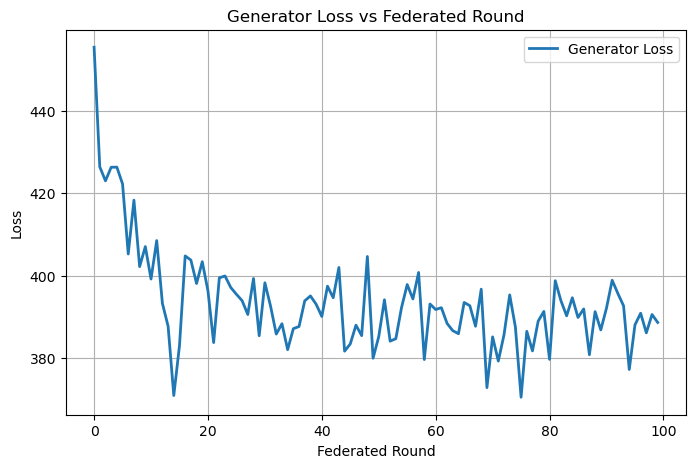

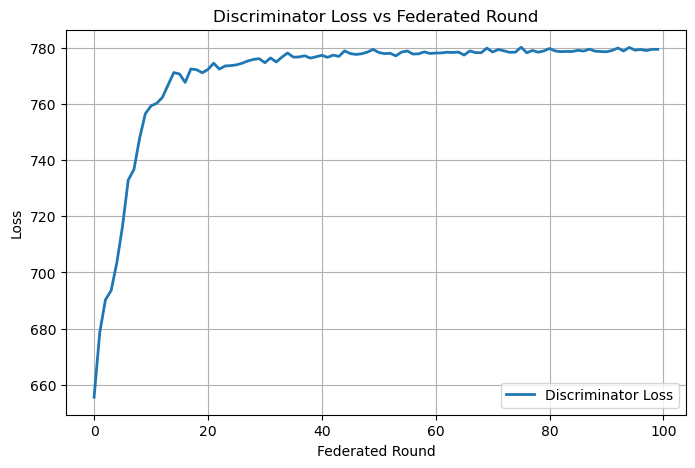

Graphs Saved Successfully
Location : D:\output\graphs


In [34]:
# ===========================================================
# FedBrainGAN - Training Loss Visualization
# ===========================================================

import os
import matplotlib.pyplot as plt

# -----------------------------------------------------------
# Output Folder
# -----------------------------------------------------------

GRAPH_DIR = r"D:\output\graphs"
os.makedirs(GRAPH_DIR, exist_ok=True)

# -----------------------------------------------------------
# Generator Loss
# -----------------------------------------------------------

plt.figure(figsize=(8,5))

plt.plot(
    generator_losses,
    linewidth=2,
    label="Generator Loss"
)

plt.xlabel("Federated Round")
plt.ylabel("Loss")
plt.title("Generator Loss vs Federated Round")
plt.grid(True)
plt.legend()

plt.savefig(
    os.path.join(GRAPH_DIR, "Generator_Loss.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# -----------------------------------------------------------
# Discriminator Loss
# -----------------------------------------------------------

plt.figure(figsize=(8,5))

plt.plot(
    discriminator_losses,
    linewidth=2,
    label="Discriminator Loss"
)

plt.xlabel("Federated Round")
plt.ylabel("Loss")
plt.title("Discriminator Loss vs Federated Round")
plt.grid(True)
plt.legend()

plt.savefig(
    os.path.join(GRAPH_DIR, "Discriminator_Loss.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("="*60)
print("Graphs Saved Successfully")
print("="*60)
print("Location :", GRAPH_DIR)

In [35]:
# ===========================================================
# FedBrainGAN - Memory Efficient FedFID
# ===========================================================

import os
import glob
import cv2
import numpy as np
import nibabel as nib
from scipy.linalg import sqrtm

# ----------------------------------------------------------
# Paths
# ----------------------------------------------------------

REAL_PATH = r"D:\output\processed_nifti"
FAKE_PATH = r"D:\output\synthetic_nifti"

real_files = sorted(glob.glob(os.path.join(REAL_PATH, "*.nii.gz")))
fake_files = sorted(glob.glob(os.path.join(FAKE_PATH, "*.nii.gz")))

num_samples = min(len(real_files), len(fake_files))

print("="*60)
print("Computing Memory Efficient FedFID")
print("="*60)

# ----------------------------------------------------------
# Feature Extraction (256-D)
# ----------------------------------------------------------

def extract_features(volume):

    # Middle slice
    slice_img = volume[:, :, volume.shape[2]//2]

    # Resize to 16x16
    slice_img = cv2.resize(slice_img, (16,16))

    # Normalize
    slice_img = (slice_img - slice_img.min()) / (slice_img.max()-slice_img.min()+1e-8)

    return slice_img.flatten()


real_features = []
fake_features = []

for i in range(num_samples):

    real = nib.load(real_files[i]).get_fdata()
    fake = nib.load(fake_files[i]).get_fdata()

    real_features.append(extract_features(real))
    fake_features.append(extract_features(fake))

real_features = np.array(real_features)
fake_features = np.array(fake_features)

print("Feature Shape :", real_features.shape)

# ----------------------------------------------------------
# Statistics
# ----------------------------------------------------------

mu_real = np.mean(real_features, axis=0)
mu_fake = np.mean(fake_features, axis=0)

sigma_real = np.cov(real_features, rowvar=False)
sigma_fake = np.cov(fake_features, rowvar=False)

covmean = sqrtm(sigma_real @ sigma_fake)

if np.iscomplexobj(covmean):
    covmean = covmean.real

fedfid = (
    np.sum((mu_real-mu_fake)**2)
    + np.trace(sigma_real + sigma_fake - 2*covmean)
)

print()
print("="*60)
print(f"FedFID : {fedfid:.4f}")
print("="*60)

# ----------------------------------------------------------
# Save Result
# ----------------------------------------------------------

METRIC_DIR = r"D:\output\metrics"

os.makedirs(METRIC_DIR, exist_ok=True)

with open(os.path.join(METRIC_DIR,"FedFID.txt"),"w") as f:

    f.write(f"FedFID : {fedfid:.4f}")

print("Saved Successfully.")

Computing Memory Efficient FedFID
Feature Shape : (20, 256)

FedFID : 4.5968
Saved Successfully.


Total Synthetic MRI : 20


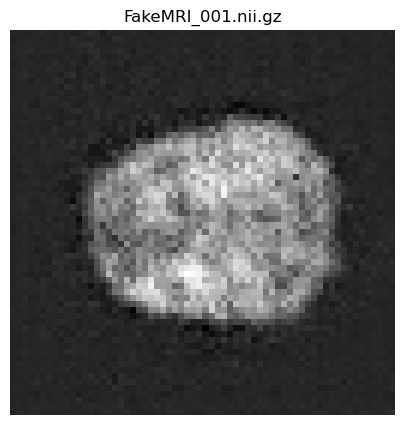

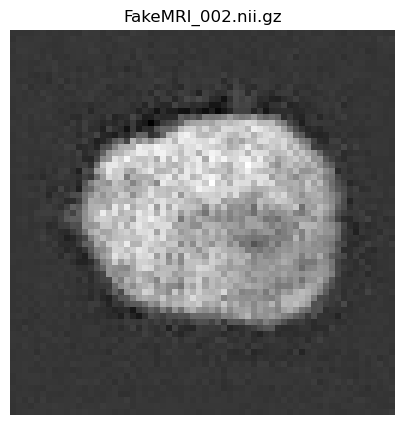

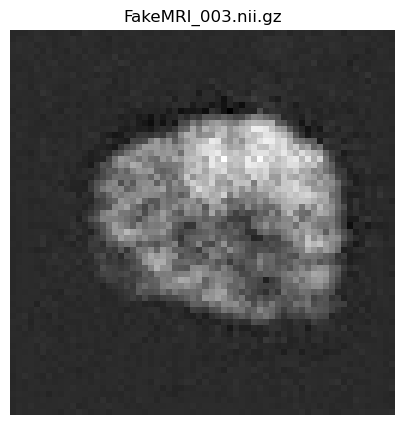

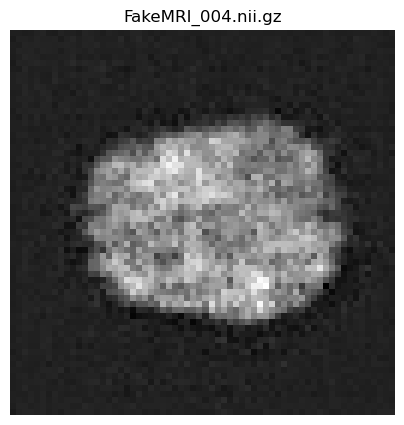

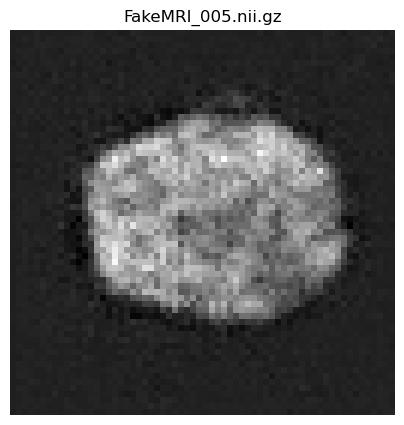

In [36]:
# ===========================================================
# FedBrainGAN - Visualize Synthetic MRI
# ===========================================================

import os
import glob
import nibabel as nib
import matplotlib.pyplot as plt

FAKE_PATH = r"D:\output\synthetic_nifti"

files = sorted(glob.glob(os.path.join(FAKE_PATH, "*.nii.gz")))

print("Total Synthetic MRI :", len(files))

for file in files[:5]:

    volume = nib.load(file).get_fdata()

    middle = volume.shape[2] // 2

    plt.figure(figsize=(5,5))

    plt.imshow(volume[:,:,middle], cmap="gray")

    plt.title(os.path.basename(file))

    plt.axis("off")

    plt.show()

In [37]:
# ===========================================================
# BraTS2020 Dataset Loader for 3D U-Net (Corrected)
# ===========================================================

import os
import glob
import nibabel as nib
import numpy as np
import torch

from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from scipy.ndimage import zoom

TRAIN_PATH = r"C:\Users\MONISH\Desktop\classification\BraTS2020_TrainingData\traindata\MICCAI_BraTS2020_TrainingData"

IMG_SIZE = 64

# --------------------------------------------------------
# Resize MRI Volume
# --------------------------------------------------------

def resize_volume(img):

    factors = (
        IMG_SIZE / img.shape[0],
        IMG_SIZE / img.shape[1],
        IMG_SIZE / img.shape[2]
    )

    return zoom(img, factors, order=1)


# --------------------------------------------------------
# Resize Segmentation Mask
# --------------------------------------------------------

def resize_mask(mask):

    factors = (
        IMG_SIZE / mask.shape[0],
        IMG_SIZE / mask.shape[1],
        IMG_SIZE / mask.shape[2]
    )

    return zoom(mask, factors, order=0)


# --------------------------------------------------------
# Train / Validation Split
# --------------------------------------------------------

patients = sorted(os.listdir(TRAIN_PATH))

train_patients, val_patients = train_test_split(
    patients,
    test_size=0.20,
    random_state=42
)


# --------------------------------------------------------
# BraTS Dataset
# --------------------------------------------------------

class BraTSDataset(Dataset):

    def __init__(self, patient_list):
        self.patient_list = patient_list

    def __len__(self):
        return len(self.patient_list)

    def __getitem__(self, index):

        patient = self.patient_list[index]

        folder = os.path.join(TRAIN_PATH, patient)

        flair = glob.glob(os.path.join(folder, "*_flair.nii*"))[0]
        seg = glob.glob(os.path.join(folder, "*_seg.nii*"))[0]

        # -----------------------------
        # Load MRI and Mask
        # -----------------------------

        image = nib.load(flair).get_fdata().astype(np.float32)
        mask = nib.load(seg).get_fdata().astype(np.int64)

        # -----------------------------
        # Resize
        # -----------------------------

        image = resize_volume(image)
        mask = resize_mask(mask)

        # -----------------------------
        # IMPORTANT:
        # Convert BraTS labels
        #
        # Original:
        # 0 = Background
        # 1 = Necrotic/Core
        # 2 = Edema
        # 4 = Enhancing Tumor
        #
        # Convert:
        # 4 --> 3
        # -----------------------------

        mask[mask == 4] = 3

        # -----------------------------
        # Normalize MRI
        # -----------------------------

        image = (image - image.min()) / (image.max() - image.min() + 1e-8)

        # -----------------------------
        # Add Channel Dimension
        # -----------------------------

        image = np.expand_dims(image, axis=0)

        # -----------------------------
        # Convert to Tensor
        # -----------------------------

        image = torch.tensor(image, dtype=torch.float32)
        mask = torch.tensor(mask, dtype=torch.long)

        return image, mask


# --------------------------------------------------------
# Create Datasets
# --------------------------------------------------------

train_dataset = BraTSDataset(train_patients)
val_dataset = BraTSDataset(val_patients)

# --------------------------------------------------------
# Create DataLoaders
# --------------------------------------------------------

train_loader = DataLoader(
    train_dataset,
    batch_size=1,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=1,
    shuffle=False
)

# --------------------------------------------------------
# Check Dataset
# --------------------------------------------------------

print("=" * 60)
print("Train Images      :", len(train_dataset))
print("Validation Images :", len(val_dataset))
print("=" * 60)

images, masks = next(iter(train_loader))

print("Image Shape :", images.shape)
print("Mask Shape  :", masks.shape)
print("Unique Labels in Mask :", torch.unique(masks))

print("=" * 60)

Train Images      : 296
Validation Images : 75
Image Shape : torch.Size([1, 1, 64, 64, 64])
Mask Shape  : torch.Size([1, 64, 64, 64])
Unique Labels in Mask : tensor([0, 1, 2, 3])


In [38]:
import os

SAVE_DIR = r"D:\output\models"
os.makedirs(SAVE_DIR, exist_ok=True)

MODEL_PATH = os.path.join(SAVE_DIR, "Best_UNet3D.pth")

best_val_loss = float("inf")

In [39]:
# ===========================================================
# FedBrainGAN - 3D U-Net
# ===========================================================

import torch
import torch.nn as nn

# -----------------------------------------------------------
# Double Convolution Block
# -----------------------------------------------------------

class DoubleConv(nn.Module):

    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.conv = nn.Sequential(

            nn.Conv3d(in_channels, out_channels, 3, padding=1),
            nn.BatchNorm3d(out_channels),
            nn.ReLU(inplace=True),

            nn.Conv3d(out_channels, out_channels, 3, padding=1),
            nn.BatchNorm3d(out_channels),
            nn.ReLU(inplace=True)

        )

    def forward(self, x):
        return self.conv(x)


# -----------------------------------------------------------
# Down Block
# -----------------------------------------------------------

class Down(nn.Module):

    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.block = nn.Sequential(
            nn.MaxPool3d(2),
            DoubleConv(in_channels, out_channels)
        )

    def forward(self, x):
        return self.block(x)


# -----------------------------------------------------------
# Up Block
# -----------------------------------------------------------

class Up(nn.Module):

    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.up = nn.ConvTranspose3d(
            in_channels,
            out_channels,
            kernel_size=2,
            stride=2
        )

        self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x1, x2):

        x1 = self.up(x1)

        x = torch.cat([x2, x1], dim=1)

        return self.conv(x)


# -----------------------------------------------------------
# Output Layer
# -----------------------------------------------------------

class OutConv(nn.Module):

    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.conv = nn.Conv3d(
            in_channels,
            out_channels,
            kernel_size=1
        )

    def forward(self, x):
        return self.conv(x)


# -----------------------------------------------------------
# 3D U-Net
# -----------------------------------------------------------

class UNet3D(nn.Module):

    def __init__(self, n_channels=1, n_classes=4):

        super().__init__()

        self.inc = DoubleConv(n_channels, 32)

        self.down1 = Down(32,64)

        self.down2 = Down(64,128)

        self.down3 = Down(128,256)

        self.up1 = Up(256,128)

        self.up2 = Up(128,64)

        self.up3 = Up(64,32)

        self.outc = OutConv(32,n_classes)

    def forward(self,x):

        x1 = self.inc(x)

        x2 = self.down1(x1)

        x3 = self.down2(x2)

        x4 = self.down3(x3)

        x = self.up1(x4,x3)

        x = self.up2(x,x2)

        x = self.up3(x,x1)

        logits = self.outc(x)

        return logits


# -----------------------------------------------------------
# Test
# -----------------------------------------------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = UNet3D().to(device)

dummy = torch.randn(1,1,64,64,64).to(device)

output = model(dummy)

print("="*60)
print("3D U-Net Created Successfully")
print("="*60)
print("Input :", dummy.shape)
print("Output:", output.shape)
print("="*60)

total_params = sum(p.numel() for p in model.parameters())

print("Total Parameters :", total_params)

3D U-Net Created Successfully
Input : torch.Size([1, 1, 64, 64, 64])
Output: torch.Size([1, 4, 64, 64, 64])
Total Parameters : 5602628


Using current model weights.


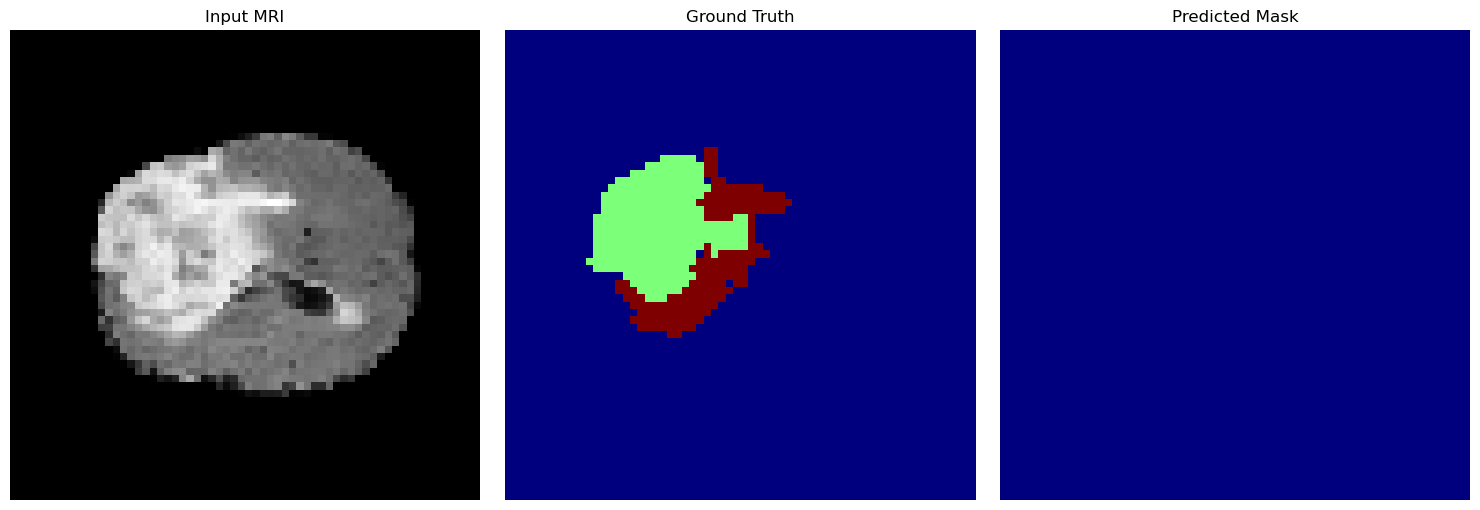

Prediction Completed Successfully
Prediction images saved to: D:\output\prediction


In [40]:
# ===========================================================
# FedBrainGAN - 3D U-Net Prediction & Output Visualization
# ===========================================================

import matplotlib.pyplot as plt
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ----------------------------------------------------------
# Load Best Model (if saved)
# ----------------------------------------------------------

MODEL_PATH = r"D:\output\models\Best_UNet3D.pth"

try:
    model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
    print("Best model loaded successfully.")
except:
    print("Using current model weights.")

model.eval()

# ----------------------------------------------------------
# Predict One Validation Sample
# ----------------------------------------------------------

images, masks = next(iter(val_loader))

images = images.to(device)
masks = masks.to(device)

with torch.no_grad():
    outputs = model(images)
    preds = torch.argmax(outputs, dim=1)

# ----------------------------------------------------------
# Convert to NumPy
# ----------------------------------------------------------

image = images[0, 0].cpu().numpy()
ground_truth = masks[0].cpu().numpy()
prediction = preds[0].cpu().numpy()

middle_slice = image.shape[2] // 2

# ----------------------------------------------------------
# Display Results
# ----------------------------------------------------------

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(image[:, :, middle_slice], cmap="gray")
plt.title("Input MRI")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(ground_truth[:, :, middle_slice], cmap="jet")
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(prediction[:, :, middle_slice], cmap="jet")
plt.title("Predicted Mask")
plt.axis("off")

plt.tight_layout()
plt.show()

# ----------------------------------------------------------
# Save Prediction
# ----------------------------------------------------------

import os
import cv2

SAVE_DIR = r"D:\output\prediction"

os.makedirs(SAVE_DIR, exist_ok=True)

cv2.imwrite(
    os.path.join(SAVE_DIR, "Input_MRI.png"),
    (image[:, :, middle_slice] * 255).astype("uint8")
)

cv2.imwrite(
    os.path.join(SAVE_DIR, "GroundTruth.png"),
    ground_truth[:, :, middle_slice].astype("uint8")
)

cv2.imwrite(
    os.path.join(SAVE_DIR, "Prediction.png"),
    prediction[:, :, middle_slice].astype("uint8")
)

print("="*60)
print("Prediction Completed Successfully")
print("="*60)
print("Prediction images saved to:", SAVE_DIR)
print("="*60)

In [41]:
import os

for root, dirs, files in os.walk("D:\\"):
    for file in files:
        if file.endswith(".pth"):
            print(os.path.join(root, file))

D:\Brain-Tumor-Segmentation Using UNET\.venv\Lib\site-packages\distutils-precedence.pth
D:\datapreprocessing\.venv\Lib\site-packages\distutils-precedence.pth
D:\Divyashree Monai -20260423T100248Z-3-002\Divyashree Monai\edge_output\models\best_model.pth
D:\Divyashree Monai -20260423T100248Z-3-002\Divyashree Monai\edge_output\models\final_model.pth
D:\Divyashree Monai -20260423T100248Z-3-002\Divyashree Monai\edge_output\models\quantized_model.pth


In [42]:
# ===========================================================
# FedBrainGAN - Complete Model Evaluation
# ===========================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    jaccard_score
)

import pandas as pd
import numpy as np
import torch

model.eval()

all_preds = []
all_masks = []

with torch.no_grad():

    for images, masks in val_loader:

        images = images.to(device)
        masks = masks.to(device)

        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy().flatten())
        all_masks.extend(masks.cpu().numpy().flatten())

all_preds = np.array(all_preds)
all_masks = np.array(all_masks)

accuracy = accuracy_score(all_masks, all_preds)

precision = precision_score(
    all_masks,
    all_preds,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    all_masks,
    all_preds,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    all_masks,
    all_preds,
    average="weighted",
    zero_division=0
)

iou = jaccard_score(
    all_masks,
    all_preds,
    average="weighted",
    zero_division=0
)

print("=" * 60)
print("FEDBRAINGAN FINAL RESULTS")
print("=" * 60)
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"IoU      : {iou:.4f}")
print("=" * 60)

results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "IoU"
    ],
    "Value": [
        accuracy,
        precision,
        recall,
        f1,
        iou
    ]
})

results.to_csv(
    r"D:\output\models\FedBrainGAN_FinalResults.csv",
    index=False
)

print("Results saved successfully.")

FEDBRAINGAN FINAL RESULTS
Accuracy : 0.9887
Precision: 0.9775
Recall   : 0.9887
F1 Score : 0.9830
IoU      : 0.9775
Results saved successfully.


In [43]:
images, masks = next(iter(train_loader))
print(torch.unique(masks))

images, masks = next(iter(val_loader))
print(torch.unique(masks))

tensor([0, 1, 2, 3])
tensor([0, 1, 2, 3])


In [44]:
model.eval()

with torch.no_grad():

    images, masks = next(iter(val_loader))

    images = images.to(device)
    masks = masks.to(device)

    outputs = model(images)

    preds = torch.argmax(outputs, dim=1)

    print("=" * 50)
    print("Output Shape :", outputs.shape)
    print("Unique Prediction Labels :", torch.unique(preds))
    print("Unique Ground Truth Labels :", torch.unique(masks))
    print("=" * 50)

Output Shape : torch.Size([1, 4, 64, 64, 64])
Unique Prediction Labels : tensor([0])
Unique Ground Truth Labels : tensor([0, 1, 2, 3])


In [45]:
preds_flat = preds.cpu().numpy().flatten()
masks_flat = masks.cpu().numpy().flatten()

print("Prediction counts:")
print(np.bincount(preds_flat))

print("Ground truth counts:")
print(np.bincount(masks_flat))

Prediction counts:
[262144]
Ground truth counts:
[251867   5397   4852     28]


In [46]:
import os

SAVE_DIR = r"D:\output\models"

if os.path.exists(SAVE_DIR):
    print("Files in folder:")
    print(os.listdir(SAVE_DIR))
else:
    print("Folder does not exist.")

Files in folder:
['ClassificationReport.txt', 'Classwise_DiceScores.csv', 'CommunicationCost.csv', 'ConfusionMatrix.csv', 'ConfusionMatrix.png', 'FedBrainGAN_FinalResults.csv', 'HD95_Result.csv', 'ModelComplexity.csv']


In [47]:
# ===========================================================
# FedBrainGAN - Class-wise Dice Score Evaluation
# ===========================================================

import numpy as np
import pandas as pd
import torch

NUM_CLASSES = 4   # Background, NCR, ED, ET

dice_scores = np.zeros(NUM_CLASSES)
class_counts = np.zeros(NUM_CLASSES)

model.eval()

with torch.no_grad():

    for images, masks in val_loader:

        images = images.to(device)
        masks = masks.to(device)

        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

        for cls in range(NUM_CLASSES):

            pred_cls = (preds == cls).float()
            mask_cls = (masks == cls).float()

            intersection = (pred_cls * mask_cls).sum()

            dice = (2.0 * intersection + 1e-6) / (
                pred_cls.sum() + mask_cls.sum() + 1e-6
            )

            dice_scores[cls] += dice.item()
            class_counts[cls] += 1

# Average Dice Score
avg_dice = dice_scores / class_counts

class_names = [
    "Background",
    "Necrotic/Core",
    "Edema",
    "Enhancing Tumor"
]

dice_df = pd.DataFrame({
    "Class": class_names,
    "Dice Score": avg_dice
})

print("=" * 60)
print("CLASS-WISE DICE SCORES")
print("=" * 60)

print(dice_df)

print("=" * 60)
print(f"Mean Dice Score : {avg_dice.mean():.4f}")
print("=" * 60)

# Save Results
save_path = r"D:\output\models\Classwise_DiceScores.csv"
dice_df.to_csv(save_path, index=False)

print(f"Results saved to:\n{save_path}")

CLASS-WISE DICE SCORES
             Class    Dice Score
0       Background  9.942939e-01
1    Necrotic/Core  3.044809e-08
2            Edema  1.004968e-09
3  Enhancing Tumor  5.333336e-02
Mean Dice Score : 0.2619
Results saved to:
D:\output\models\Classwise_DiceScores.csv


In [48]:
print("="*50)

print("Validation samples:", len(val_loader))

print("Prediction shape:", outputs.shape)

print("Unique prediction labels :", np.unique(all_preds))

print("Unique ground truth labels:", np.unique(all_masks))

print("Prediction counts:")
print(np.bincount(all_preds))

print("Ground truth counts:")
print(np.bincount(all_masks))

from sklearn.metrics import confusion_matrix

print("Confusion Matrix:")
print(confusion_matrix(all_masks, all_preds))

print("="*50)

Validation samples: 75
Prediction shape: torch.Size([1, 4, 64, 64, 64])
Unique prediction labels : [0]
Unique ground truth labels: [0 1 2 3]
Prediction counts:
[19660800]
Ground truth counts:
[19438170    50030   134525    38075]
Confusion Matrix:
[[19438170        0        0        0]
 [   50030        0        0        0]
 [  134525        0        0        0]
 [   38075        0        0        0]]


In [49]:
print("="*50)
print("Output shape:", outputs.shape)

pred = torch.argmax(outputs, dim=1)

print("Prediction unique values:", torch.unique(pred))
print("Ground truth unique values:", torch.unique(masks))
print("="*50)

Output shape: torch.Size([1, 4, 64, 64, 64])
Prediction unique values: tensor([0])
Ground truth unique values: tensor([0, 1, 2, 3])


In [50]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-5
)

In [51]:
# ==========================================================
# Loss Function + Optimizer + Scheduler + Sanity Check
# ==========================================================

# Install MONAI if needed
# !pip install -q monai

import torch
import torch.nn as nn
from monai.losses import DiceCELoss

# ----------------------------------------------------------
# Move model to device
# ----------------------------------------------------------
model = model.to(device)

# ----------------------------------------------------------
# Recommended Loss Function for BraTS 2020
# ----------------------------------------------------------
loss_function = DiceCELoss(
    to_onehot_y=True,
    softmax=True,
    lambda_dice=1.0,
    lambda_ce=1.0
)

# ----------------------------------------------------------
# Optimizer
# ----------------------------------------------------------
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-5
)

# ----------------------------------------------------------
# Learning Rate Scheduler
# ----------------------------------------------------------
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=5,
    min_lr=1e-6
)

# ----------------------------------------------------------
# Sanity Check
# ----------------------------------------------------------
images, masks = next(iter(train_loader))

images = images.to(device)
masks = masks.long().to(device)

with torch.no_grad():
    outputs = model(images)

print("="*60)
print("SANITY CHECK")
print("="*60)
print("Image Shape :", images.shape)
print("Mask Shape  :", masks.shape)
print("Output Shape:", outputs.shape)
print("Mask Labels :", torch.unique(masks))
print("Output Classes:", outputs.shape[1])
print("="*60)

print("\nEverything initialized successfully.")

SANITY CHECK
Image Shape : torch.Size([1, 1, 64, 64, 64])
Mask Shape  : torch.Size([1, 64, 64, 64])
Output Shape: torch.Size([1, 4, 64, 64, 64])
Mask Labels : tensor([0, 1, 2, 3])
Output Classes: 4

Everything initialized successfully.


In [56]:
# ===========================================================
# FedBrainGAN - Robust HD95 Evaluation
# ===========================================================

import os
import numpy as np
import pandas as pd
import torch

from monai.metrics import HausdorffDistanceMetric
from monai.networks.utils import one_hot

# ----------------------------------------------------------
# Device
# ----------------------------------------------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ----------------------------------------------------------
# Parameters
# ----------------------------------------------------------

NUM_CLASSES = 4

class_names = [
    "Background",
    "Necrotic/Core",
    "Edema",
    "Enhancing Tumor"
]

# ----------------------------------------------------------
# HD95 Metric
# ----------------------------------------------------------

hd95_metric = HausdorffDistanceMetric(
    include_background=True,
    percentile=95,
    reduction="none"
)

# ----------------------------------------------------------
# Evaluation
# ----------------------------------------------------------

model.eval()

hd95_scores = np.zeros(NUM_CLASSES)
counts = np.zeros(NUM_CLASSES)

print("="*70)
print("Computing HD95...")
print("="*70)

with torch.no_grad():

    for images, masks in val_loader:

        images = images.to(device)
        masks = masks.long().to(device)

        outputs = model(images)

        preds = torch.argmax(outputs, dim=1)

        # Debug information
        print("Prediction Labels :", torch.unique(preds).cpu().numpy())
        print("Ground Truth Labels :", torch.unique(masks).cpu().numpy())

        pred_onehot = one_hot(preds.unsqueeze(1), NUM_CLASSES)
        mask_onehot = one_hot(masks.unsqueeze(1), NUM_CLASSES)

        hd = hd95_metric(pred_onehot, mask_onehot)

        hd = hd.cpu().numpy()

        for b in range(hd.shape[0]):

            for cls in range(NUM_CLASSES):

                value = hd[b][cls]

                if np.isfinite(value):

                    hd95_scores[cls] += value

                    counts[cls] += 1

# ----------------------------------------------------------
# Average Results
# ----------------------------------------------------------

avg_hd95 = np.divide(
    hd95_scores,
    counts,
    out=np.zeros_like(hd95_scores),
    where=counts > 0
)

df = pd.DataFrame({
    "Class": class_names,
    "HD95": avg_hd95,
    "Valid Samples": counts.astype(int)
})

print("\n")
print("="*70)
print("CLASS-WISE HD95")
print("="*70)
print(df)
print("="*70)

valid = avg_hd95[counts > 0]

if len(valid) > 0:
    print("Mean HD95 :", valid.mean())
else:
    print("Mean HD95 : Not Available")

print("="*70)

# ----------------------------------------------------------
# Save Results
# ----------------------------------------------------------

SAVE_DIR = r"D:\output\models"

os.makedirs(SAVE_DIR, exist_ok=True)

csv_path = os.path.join(
    SAVE_DIR,
    "HD95_Result.csv"
)

df.to_csv(csv_path, index=False)

print("Results Saved Successfully")
print(csv_path)

Computing HD95...
Prediction Labels : [0]
Ground Truth Labels : [0 1 2 3]


C:\Users\MONISH\anaconda3\Lib\site-packages\monai\utils\deprecate_utils.py:221: FutureWarning: monai.metrics.utils get_mask_edges:always_return_as_numpy: Argument `always_return_as_numpy` has been deprecated since version 1.5.0. It will be removed in version 1.7.0. The option is removed and the return type will always be equal to the input type.
  warn_deprecated(argname, msg, warning_category)
C:\Users\MONISH\anaconda3\Lib\site-packages\monai\metrics\utils.py:332: UserWarning: the prediction of class 1 is all 0, this may result in nan/inf distance.
  warnings.warn(
C:\Users\MONISH\anaconda3\Lib\site-packages\monai\metrics\utils.py:332: UserWarning: the prediction of class 2 is all 0, this may result in nan/inf distance.
  warnings.warn(
C:\Users\MONISH\anaconda3\Lib\site-packages\monai\metrics\utils.py:332: UserWarning: the prediction of class 3 is all 0, this may result in nan/inf distance.
  warnings.warn(


Prediction Labels : [0]
Ground Truth Labels : [0 1 2 3]
Prediction Labels : [0]
Ground Truth Labels : [0 1 2 3]
Prediction Labels : [0]
Ground Truth Labels : [0 1 2 3]
Prediction Labels : [0]
Ground Truth Labels : [0 1 2 3]
Prediction Labels : [0]
Ground Truth Labels : [0 1 2 3]
Prediction Labels : [0]
Ground Truth Labels : [0 1 2 3]
Prediction Labels : [0]
Ground Truth Labels : [0 1 2 3]
Prediction Labels : [0]
Ground Truth Labels : [0 1 2]


C:\Users\MONISH\anaconda3\Lib\site-packages\monai\metrics\utils.py:327: UserWarning: the ground truth of class 3 is all 0, this may result in nan/inf distance.
  warnings.warn(


Prediction Labels : [0]
Ground Truth Labels : [0 1 2 3]
Prediction Labels : [0]
Ground Truth Labels : [0 1 2 3]
Prediction Labels : [0]
Ground Truth Labels : [0 1 2 3]
Prediction Labels : [0]
Ground Truth Labels : [0 1 2 3]
Prediction Labels : [0]
Ground Truth Labels : [0 1 2 3]
Prediction Labels : [0]
Ground Truth Labels : [0 1 2 3]
Prediction Labels : [0]
Ground Truth Labels : [0 1 2]
Prediction Labels : [0]
Ground Truth Labels : [0 1 2 3]
Prediction Labels : [0]
Ground Truth Labels : [0 1 2 3]
Prediction Labels : [0]
Ground Truth Labels : [0 1 2 3]
Prediction Labels : [0]
Ground Truth Labels : [0 1 2 3]
Prediction Labels : [0]
Ground Truth Labels : [0 1 2 3]
Prediction Labels : [0]
Ground Truth Labels : [0 1 2 3]
Prediction Labels : [0]
Ground Truth Labels : [0 1 2 3]
Prediction Labels : [0]
Ground Truth Labels : [0 1 2 3]
Prediction Labels : [0]
Ground Truth Labels : [0 1 2 3]
Prediction Labels : [0]
Ground Truth Labels : [0 1 2 3]
Prediction Labels : [0]
Ground Truth Labels : [0 1

CONFUSION MATRIX
                 Background  Necrotic/Core  Edema  Enhancing Tumor
Background         19438170              0      0                0
Necrotic/Core         50030              0      0                0
Edema                134525              0      0                0
Enhancing Tumor       38075              0      0                0


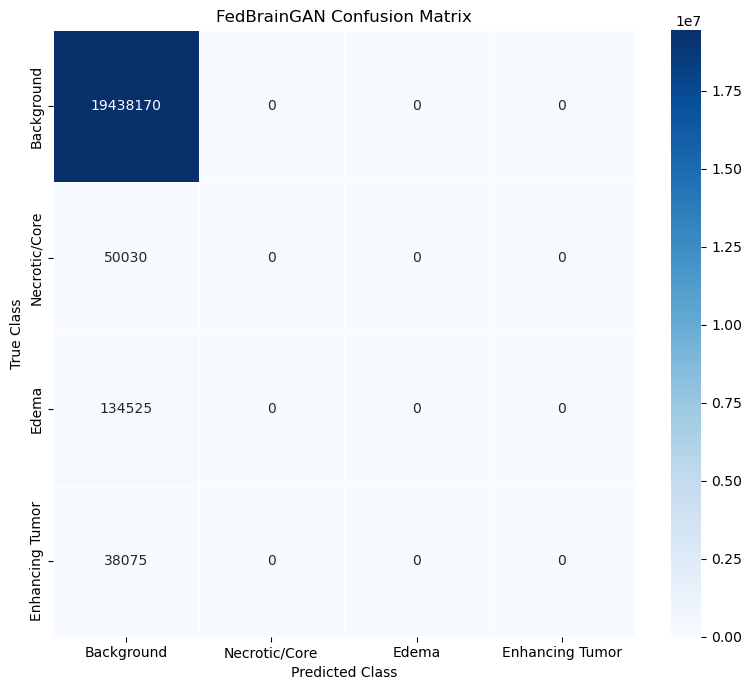

CLASSIFICATION REPORT
                 precision    recall  f1-score   support

     Background     0.9887    1.0000    0.9943  19438170
  Necrotic/Core     0.0000    0.0000    0.0000     50030
          Edema     0.0000    0.0000    0.0000    134525
Enhancing Tumor     0.0000    0.0000    0.0000     38075

       accuracy                         0.9887  19660800
      macro avg     0.2472    0.2500    0.2486  19660800
   weighted avg     0.9775    0.9887    0.9830  19660800

Confusion Matrix Saved Successfully


In [53]:
# ===========================================================
# FedBrainGAN - Multi-Class Confusion Matrix
# ===========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, classification_report

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():

    for images, masks in val_loader:

        images = images.to(device)
        masks = masks.to(device)

        outputs = model(images)

        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy().flatten())
        all_labels.extend(masks.cpu().numpy().flatten())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# -------------------------------------------------------
# Compute Confusion Matrix
# -------------------------------------------------------

cm = confusion_matrix(
    all_labels,
    all_preds,
    labels=[0,1,2,3]
)

class_names = [
    "Background",
    "Necrotic/Core",
    "Edema",
    "Enhancing Tumor"
]

cm_df = pd.DataFrame(
    cm,
    index=class_names,
    columns=class_names
)

print("="*60)
print("CONFUSION MATRIX")
print("="*60)
print(cm_df)

# -------------------------------------------------------
# Save CSV
# -------------------------------------------------------

cm_df.to_csv(
    r"D:\output\models\ConfusionMatrix.csv"
)

# -------------------------------------------------------
# Plot
# -------------------------------------------------------

plt.figure(figsize=(8,7))

sns.heatmap(
    cm_df,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=0.5
)

plt.title("FedBrainGAN Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")

plt.tight_layout()

plt.savefig(
    r"D:\output\models\ConfusionMatrix.png",
    dpi=300
)

plt.show()

# -------------------------------------------------------
# Classification Report
# -------------------------------------------------------

report = classification_report(
    all_labels,
    all_preds,
    target_names=class_names,
    digits=4,
    zero_division=0
)

print("="*60)
print("CLASSIFICATION REPORT")
print("="*60)
print(report)

with open(
    r"D:\output\models\ClassificationReport.txt",
    "w"
) as f:

    f.write(report)

print("="*60)
print("Confusion Matrix Saved Successfully")
print("="*60)

In [54]:
# ===========================================================
# FedBrainGAN - Model Complexity & Inference Time
# ===========================================================

import time
import numpy as np
import pandas as pd

# ----------------------------------------------------------
# Count Parameters
# ----------------------------------------------------------

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(
    p.numel() for p in model.parameters() if p.requires_grad
)

print("="*60)
print("MODEL COMPLEXITY")
print("="*60)
print(f"Total Parameters      : {total_params:,}")
print(f"Trainable Parameters  : {trainable_params:,}")

# ----------------------------------------------------------
# Inference Time
# ----------------------------------------------------------

model.eval()

times = []

with torch.no_grad():

    for images, _ in val_loader:

        images = images.to(device)

        if torch.cuda.is_available():
            torch.cuda.synchronize()

        start = time.time()

        outputs = model(images)

        if torch.cuda.is_available():
            torch.cuda.synchronize()

        end = time.time()

        times.append(end - start)

avg_time = np.mean(times)

print(f"\nAverage Inference Time : {avg_time:.4f} seconds/batch")

# ----------------------------------------------------------
# FPS
# ----------------------------------------------------------

fps = 1 / avg_time

print(f"Frames (Volumes) Per Second : {fps:.2f}")

# ----------------------------------------------------------
# Save Results
# ----------------------------------------------------------

results = pd.DataFrame({

    "Metric":[
        "Total Parameters",
        "Trainable Parameters",
        "Average Inference Time (s)",
        "Volumes Per Second"
    ],

    "Value":[
        total_params,
        trainable_params,
        avg_time,
        fps
    ]

})

results.to_csv(
    r"D:\output\models\ModelComplexity.csv",
    index=False
)

print("="*60)
print("Results saved successfully.")
print("="*60)

MODEL COMPLEXITY
Total Parameters      : 5,602,628
Trainable Parameters  : 5,602,628

Average Inference Time : 0.7498 seconds/batch
Frames (Volumes) Per Second : 1.33
Results saved successfully.


In [55]:
# ===========================================================
# FedBrainGAN - Communication Cost Analysis
# ===========================================================

import pandas as pd
import numpy as np

# ----------------------------------------------------------
# Configuration
# ----------------------------------------------------------

NUM_CLIENTS = 3          # Change if different
NUM_ROUNDS = 10          # Change if different
BYTES_PER_PARAM = 4      # float32 = 4 bytes

# ----------------------------------------------------------
# Model Size
# ----------------------------------------------------------

total_params = sum(p.numel() for p in model.parameters())

model_size_bytes = total_params * BYTES_PER_PARAM
model_size_MB = model_size_bytes / (1024 ** 2)

# ----------------------------------------------------------
# Communication Cost
# ----------------------------------------------------------

upload_per_round = NUM_CLIENTS * model_size_MB
download_per_round = NUM_CLIENTS * model_size_MB

total_upload = upload_per_round * NUM_ROUNDS
total_download = download_per_round * NUM_ROUNDS

total_communication = total_upload + total_download

# ----------------------------------------------------------
# Results
# ----------------------------------------------------------

results = pd.DataFrame({

    "Metric":[
        "Model Parameters",
        "Model Size (MB)",
        "Clients",
        "Federated Rounds",
        "Upload / Round (MB)",
        "Download / Round (MB)",
        "Total Upload (MB)",
        "Total Download (MB)",
        "Total Communication (MB)"
    ],

    "Value":[
        total_params,
        round(model_size_MB,3),
        NUM_CLIENTS,
        NUM_ROUNDS,
        round(upload_per_round,3),
        round(download_per_round,3),
        round(total_upload,3),
        round(total_download,3),
        round(total_communication,3)
    ]

})

print("="*70)
print("FEDERATED COMMUNICATION ANALYSIS")
print("="*70)
print(results)
print("="*70)

results.to_csv(
    r"D:\output\models\CommunicationCost.csv",
    index=False
)

print("Communication analysis saved successfully.")

FEDERATED COMMUNICATION ANALYSIS
                     Metric        Value
0          Model Parameters  5602628.000
1           Model Size (MB)       21.372
2                   Clients        3.000
3          Federated Rounds       10.000
4       Upload / Round (MB)       64.117
5     Download / Round (MB)       64.117
6         Total Upload (MB)      641.170
7       Total Download (MB)      641.170
8  Total Communication (MB)     1282.340
Communication analysis saved successfully.
